In [1]:
from sunpy.map import Map, all_coordinates_from_map
from astropy.io import fits
import matplotlib.pyplot as plt
import os
import numpy as np
from dateutil.parser import parse

from itipy.data import editor, dataset
from itipy.data.dataset import BaseDataset, KSOFlatDataset, KSODataset

In [2]:
class Low1920(BaseDataset):
    def __init__(self, root, resolution=2048, ext='.fits', date_parser=None, **kw):
        editors = [
            editor.LoadMapEditor(),
            editor.FixDateEditor(),
            editor.KSOPrepEditor(),
            editor.NormalizeRadiusEditor(resolution, 0),
            editor.LimbDarkeningCorrectionEditor(),
            editor.MapToDataEditor(),
            editor.ImageNormalizeEditor(0.65, 1.5, stretch=editor.AsinhStretch(0.5)),
            editor.NanEditor(-1),
            editor.ReshapeEditor((1,resolution,resolution)),
        ]
        if date_parser is None:
            date_parser = lambda f: parse(os.path.basename(f)[3:-9])
        super().__init__(root, editors=editors, ext=ext, date_parser=date_parser, **kw)

class High2014(BaseDataset):
    def __init__(self, root, **kw):
        editors = [
            editor.LoadMapEditor(),
            editor.KSOPrepEditor(),
            editor.NormalizeRadiusEditor(2048, 0),
            editor.MapToDataEditor(),
            editor.ImageNormalizeEditor(0, 1000, stretch=editor.AsinhStretch(0.5)),
            editor.NanEditor(-1),
            editor.ReshapeEditor((1,2048,2048)),
        ]
        super().__init__(root, editors=editors, ext=".fts", **kw)

In [15]:
high_2017 = KSOFlatDataset(r'/home/jhpan/ITI/InstrumentToInstrument/dataset/2017_fits', resolution=2048, months=[11, 12])

In [16]:
len(high_2017)

47

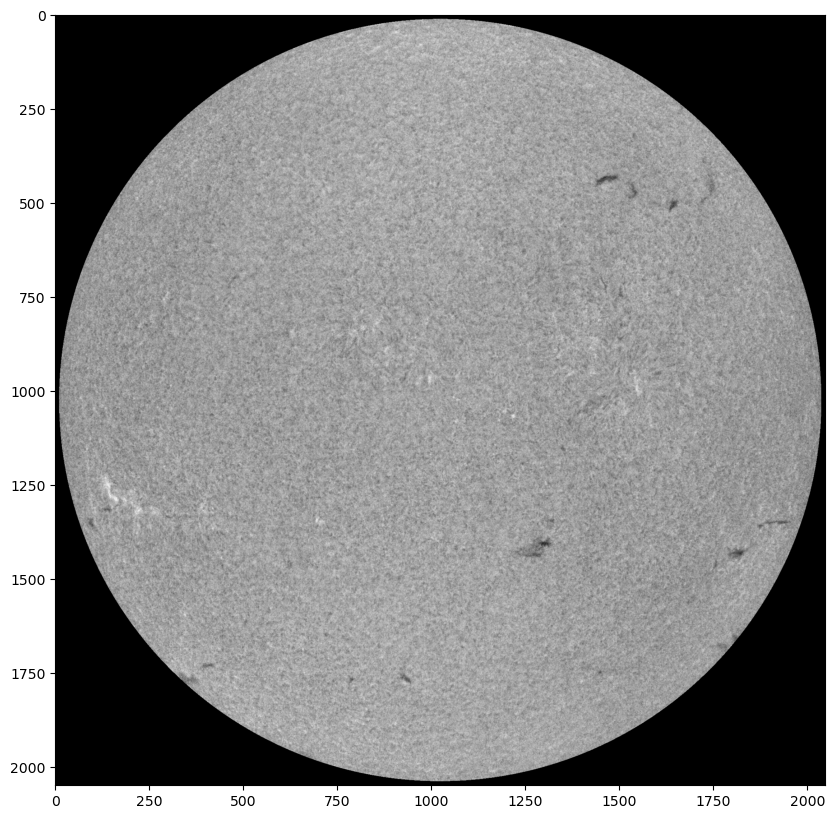

In [14]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(high_2017[0][0, :, :], cmap='gray')

In [19]:
low_1920 = Low1920(r'/home/jhpan/ITI/InstrumentToInstrument/dataset/1920_fits', months=list(range(11)))

In [20]:
len(low_1920)

204

In [41]:
low_1920[0].shape

(1, 2048, 2048)

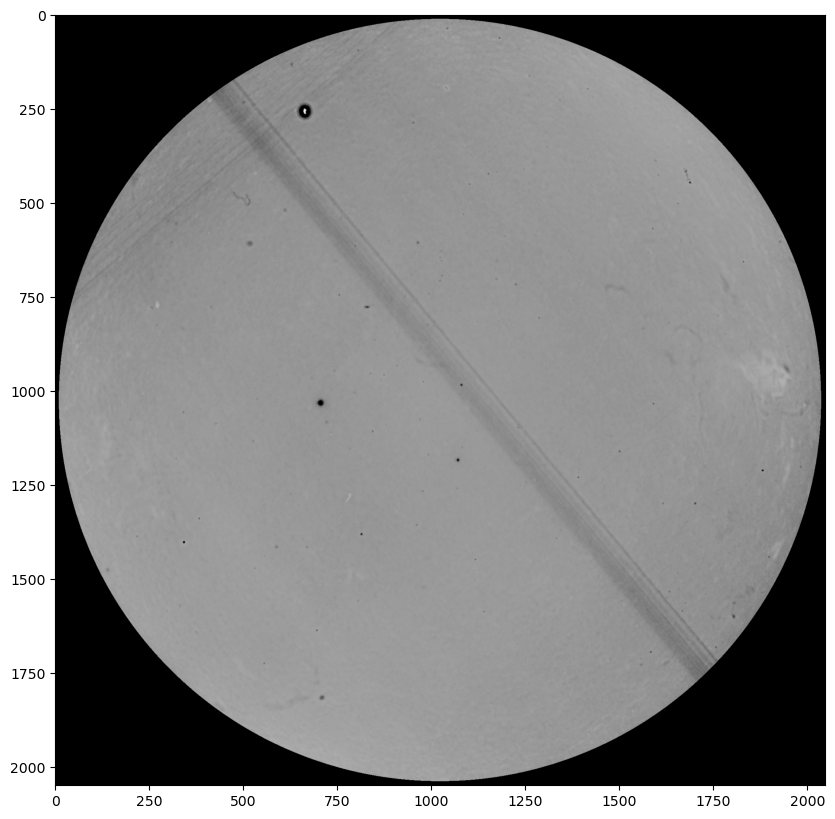

In [42]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(low_1920[0][0, :, :], cmap='gray')

In [58]:
high_2014 = High2014(r'/home/jhpan/ITI/InstrumentToInstrument/dataset/2014_fits')

In [59]:
len(high_2014)

165

In [60]:
high_2014[0].shape

(1, 2048, 2048)

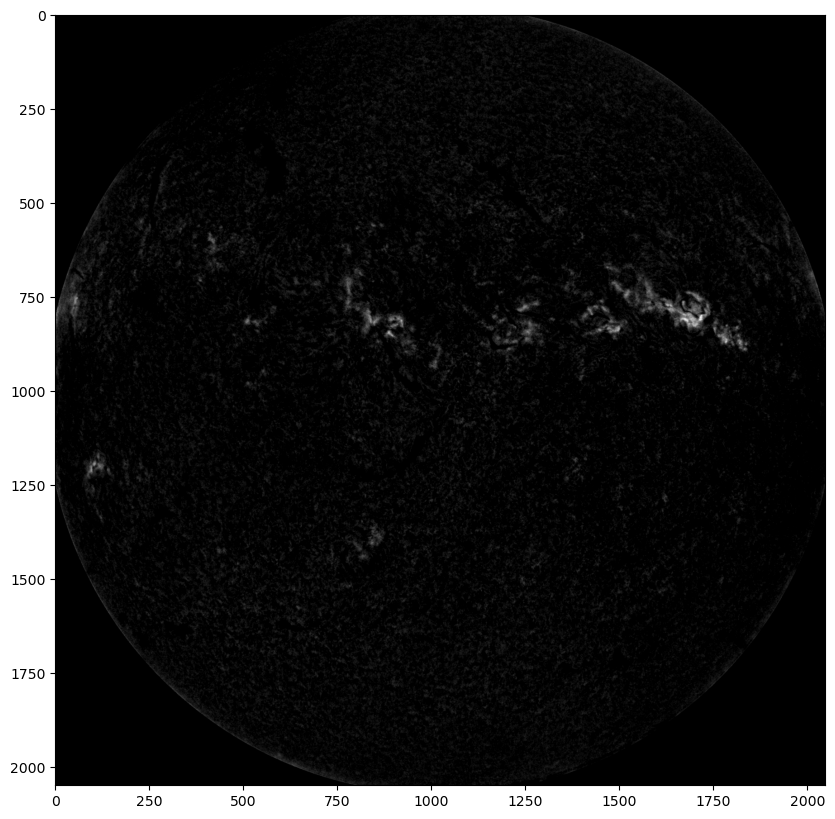

In [61]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(high_2014[0][0, :, :], cmap='gray')

In [11]:
from tqdm import tqdm
from astropy.io import fits

root_dir = r'/home/jhpan/ITI/InstrumentToInstrument/dataset/2017_fits'
save_dir = r'/home/jhpan/ITI/InstrumentToInstrument/dataset/2017_view'
fits_list = os.listdir(root_dir)
for filename in tqdm(fits_list):
    fits_file = os.path.join(root_dir, filename)
    kso_data = fits.getdata(fits_file)

    plt.figure(figsize=(10, 10))
    plt.imshow(kso_data, cmap='gray', origin='lower')

    save_path = os.path.join(save_dir, f"{os.path.splitext(filename)[0]}.png")
    plt.savefig(save_path, dpi=100)
    plt.close()

100%|██████████| 318/318 [03:39<00:00,  1.45it/s]
